# Transhipment plus Dynamic PM Handling

Why dynamic PM dispatching reduces PM requirements
Under your old model (round‑robin PM assignment):

Each PM is pre‑assigned to a TEU.

If PM\_03 is busy, but PM\_07 is idle, the QC still waits for PM\_03.

This creates artificial QC blocking.

PM idle time increases.

QC idle time increases.

Vessel completion time increases.

You compensate by adding more PMs than necessary.

This is exactly what happens in a deterministic tandem queue.


In [1]:
from datetime import datetime
import random
import simpy
import shapely.geometry
import pandas as pd
import openclsim.core as core
import openclsim.model as model
import re


def run_simulation(qc_fleet_size, pm_fleet_size, initial_teu=200, seed=None):
    if seed is not None:
        random.seed(seed)

    simulation_start = datetime(2024, 1, 1, 8, 0, 0)
    env = simpy.Environment(initial_time=simulation_start.timestamp())
    registry = {}
    teu_log = []

    # Geometry
    quay_loc = shapely.geometry.Point(24.5169154690744, 56.608466552452356)
    vessel_loc = quay_loc

    # Object classes
    Site = type(
        "Site",
        (core.Identifiable, core.Log, core.Locatable, core.HasContainer, core.HasResource),
        {},
    )
    VesselUnloader = type(
        "VesselUnloader",
        (
            core.Identifiable,
            core.ContainerDependentMovable,
            core.HasResource,
            core.Processor,
            core.LoadingFunction,
            core.UnloadingFunction,
        ),
        {},
    )
    LandTransporter = type(
        "LandTransporter",
        (
            core.Identifiable,
            core.ContainerDependentMovable,
            core.Processor,
            core.HasResource,
            core.LoadingFunction,
            core.UnloadingFunction,
        ),
        {},
    )

    # Quay + yards
    quay_site = Site(env=env, name="Quay Site", geometry=quay_loc, capacity=10_000, level=0)

    yard_specs = [
        ("Yard1", 100, 100),
        ("Yard2", 200, 100),
        ("Yard3", 300, 100),
        ("Yard4", 400, 100),
        ("Yard5", 500, 100),
    ]
    yard_by_name = {}
    remaining_cap = {}
    for name, distance, capacity in yard_specs:
        yard_loc = shapely.geometry.Point(quay_loc.x + distance * 0.00001, quay_loc.y)
        yard = Site(env=env, name=name, geometry=yard_loc, capacity=capacity, level=0)
        yard.distance = distance
        yard_by_name[name] = yard
        remaining_cap[name] = capacity

    transhipment_yards = [yard_by_name["Yard1"], yard_by_name["Yard2"], yard_by_name["Yard3"]]
    import_yards = [yard_by_name["Yard4"], yard_by_name["Yard5"]]

    def choose_yard_for_teu(is_import: bool):
        allowed = import_yards if is_import else transhipment_yards
        allowed_sorted = sorted(allowed, key=lambda y: y.distance)
        for yard in allowed_sorted:
            if remaining_cap[yard.name] > 0:
                remaining_cap[yard.name] -= 1
                return yard
        raise RuntimeError("All allowed yards for this TEU type are full in planning!")

    vessel = VesselUnloader(
        env=env,
        name="vessel01",
        geometry=vessel_loc,
        loading_rate=1,
        unloading_rate=1,
        capacity=initial_teu,
        level=initial_teu,
        compute_v=lambda x: 10,
    )

    # Parameters (seconds)
    qc_pick_time = 60
    qc_transfer_time = 60
    qc_load_to_pm_time = 120
    qc_travelback_time = 60
    pm_unload_time = 120
    pm_speed = 5

    # Fleets
    pm_fleet = []
    for i in range(1, pm_fleet_size + 1):
        pm = LandTransporter(
            env=env,
            name=f"pm_{i:02d}",
            geometry=quay_loc,
            loading_rate=1,
            unloading_rate=1,
            capacity=1,
            level=0,
            compute_v=lambda x, v=pm_speed: v,
        )
        pm_fleet.append(pm)

    qc_fleet = []
    for i in range(1, qc_fleet_size + 1):
        qc = VesselUnloader(
            env=env,
            name=f"qc_{i:02d}",
            geometry=quay_loc,
            loading_rate=1,
            unloading_rate=1,
            capacity=1,
            level=0,
            compute_v=lambda x: 10,
        )
        qc_fleet.append(qc)

    # QC and PM chaining markers (capacity safety)
    last_qc_travelback_name = {qc.name: None for qc in qc_fleet}
    last_pm_return_name = {pm.name: None for pm in pm_fleet}

    # Proxy "dynamic" PM selection
    pm_available_rank = {pm.name: 0 for pm in pm_fleet}

    # Activity collectors
    qc_pick_activities = []
    qc_transfer_activities = []
    qc_load_to_pm_activities = []
    qc_travelback_activities = []
    pm_travel_activities = []
    pm_unload_activities = []
    pm_return_activities = []

    all_jobs = []

    for n in range(1, initial_teu + 1):
        # Type + yard selection
        is_import = random.random() < 0.40
        chosen_yard = choose_yard_for_teu(is_import)
        loader = qc_fleet[(n - 1) % qc_fleet_size]

        # Proxy dynamic PM choice
        mover_name = min(pm_available_rank, key=lambda k: pm_available_rank[k])
        mover = next(pm for pm in pm_fleet if pm.name == mover_name)

        teu_log.append({
            "teu_id": n,
            "type": "IMPORT" if is_import else "TRANSHIPMENT",
            "yard": chosen_yard.name,
            "qc": loader.name,
            "pm": mover.name,
        })

        # QC pick must wait for previous QC travelback (capacity=1 safety)
        qc_pick_start_events = []
        if last_qc_travelback_name[loader.name] is not None:
            qc_pick_start_events.append(
                {"name": last_qc_travelback_name[loader.name], "type": "activity", "state": "done"}
            )

        qc_pick = model.ShiftAmountActivity(
            env=env,
            name=f"TEU_{n}_qc_pick_{loader.name}",
            registry=registry,
            processor=loader,
            origin=vessel,
            destination=loader,
            amount=1,
            duration=qc_pick_time,
            start_event=qc_pick_start_events,
        )

        qc_transfer = model.BasicActivity(
            env=env,
            name=f"TEU_{n}_qc_transfer_{loader.name}",
            registry=registry,
            duration=qc_transfer_time,
            start_event=[{"name": qc_pick.name, "type": "activity", "state": "done"}],
        )

        qc_load_start_events = [{"name": qc_transfer.name, "type": "activity", "state": "done"}]
        if last_pm_return_name[mover.name] is not None:
            qc_load_start_events.append(
                {"name": last_pm_return_name[mover.name], "type": "activity", "state": "done"}
            )

        qc_load_to_pm = model.ShiftAmountActivity(
            env=env,
            name=f"TEU_{n}_qc_load_to_pm_{mover.name}",
            registry=registry,
            processor=loader,
            origin=loader,
            destination=mover,
            amount=1,
            duration=qc_load_to_pm_time,
            start_event=qc_load_start_events,
        )

        qc_travelback = model.BasicActivity(
            env=env,
            name=f"TEU_{n}_qc_travelback_{mover.name}",
            registry=registry,
            duration=qc_travelback_time,
            start_event=[{"name": qc_load_to_pm.name, "type": "activity", "state": "done"}],
        )

        pm_travel_to_yard = model.MoveActivity(
            env=env,
            name=f"TEU_{n}_pm_travel_to_{chosen_yard.name}_{mover.name}",
            registry=registry,
            mover=mover,
            destination=chosen_yard,
            start_event=[{"name": qc_load_to_pm.name, "type": "activity", "state": "done"}],
        )

        pm_unload = model.ShiftAmountActivity(
            env=env,
            name=f"TEU_{n}_pm_unload_{chosen_yard.name}_{mover.name}",
            registry=registry,
            processor=mover,
            origin=mover,
            destination=chosen_yard,
            amount=1,
            duration=pm_unload_time,
            start_event=[{"name": pm_travel_to_yard.name, "type": "activity", "state": "done"}],
        )

        pm_return = model.MoveActivity(
            env=env,
            name=f"TEU_{n}_pm_return_{mover.name}",
            registry=registry,
            mover=mover,
            destination=quay_site,
            start_event=[{"name": pm_unload.name, "type": "activity", "state": "done"}],
        )

        last_qc_travelback_name[loader.name] = qc_travelback.name
        last_pm_return_name[mover.name] = pm_return.name

        # Include all sub-processes so OpenCLSim registers them
        job = model.ParallelActivity(
            env=env,
            name=f"TEU_{n}_job_{mover.name}",
            registry=registry,
            sub_processes=[
                qc_pick,
                qc_transfer,
                qc_load_to_pm,
                qc_travelback,
                pm_travel_to_yard,
                pm_unload,
                pm_return,
            ],
        )
        all_jobs.append(job)

        qc_pick_activities.append(qc_pick)
        qc_transfer_activities.append(qc_transfer)
        qc_load_to_pm_activities.append(qc_load_to_pm)
        qc_travelback_activities.append(qc_travelback)
        pm_travel_activities.append(pm_travel_to_yard)
        pm_unload_activities.append(pm_unload)
        pm_return_activities.append(pm_return)

        pm_available_rank[mover.name] += 1

    system = model.ParallelActivity(
        env=env,
        name="terminal_fleet_system",
        registry=registry,
        sub_processes=all_jobs,
    )
    model.register_processes([system])
    env.run()

    # Completion time
    end_times = []
    for pm in pm_fleet:
        if hasattr(pm, "log") and pm.log:
            df_log = pd.DataFrame(pm.log)
            if not df_log.empty and "Timestamp" in df_log.columns:
                end_times.append(df_log["Timestamp"].max())
    vessel_seconds = float("inf") if not end_times else max(end_times).timestamp() - simulation_start.timestamp()

    teu_df = pd.DataFrame(teu_log)

    # --------------------------------------------------
    # 11. Build detailed ordered activity event log + CSV
    # --------------------------------------------------
    def parse_activity_metadata(activity_name):
        patterns = [
            (r"^TEU_(\d+)_qc_pick_(qc_\d+)$", "qc_pick", 1),
            (r"^TEU_(\d+)_qc_transfer_(qc_\d+)$", "qc_transfer", 2),
            (r"^TEU_(\d+)_qc_load_to_pm_(pm_\d+)$", "qc_load_to_pm", 3),
            (r"^TEU_(\d+)_qc_travelback_(pm_\d+)$", "qc_travelback", 4),
            (r"^TEU_(\d+)_pm_travel_to_(Yard\d+)_(pm_\d+)$", "pm_travel_to_yard", 5),
            (r"^TEU_(\d+)_pm_unload_(Yard\d+)_(pm_\d+)$", "pm_unload", 6),
            (r"^TEU_(\d+)_pm_return_(pm_\d+)$", "pm_return", 7),
        ]
        for pattern, activity_type, activity_order in patterns:
            m = re.search(pattern, activity_name)
            if m:
                teu_id = int(m.group(1))
                pm_name = None
                for g in m.groups():
                    if isinstance(g, str) and g.startswith("pm_"):
                        pm_name = g
                        break
                return teu_id, pm_name, activity_type, activity_order
        return None, None, "unknown", 999

    activity_frames = []
    all_activities = (
        qc_pick_activities
        + qc_transfer_activities
        + qc_load_to_pm_activities
        + qc_travelback_activities
        + pm_travel_activities
        + pm_unload_activities
        + pm_return_activities
    )

    for act in all_activities:
        if hasattr(act, "log"):
            df = pd.DataFrame(act.log)
            if not df.empty:
                teu_id, pm_name, activity_type, activity_order = parse_activity_metadata(act.name)
                df = df.copy()
                df["activity_name"] = act.name
                df["teu_id"] = teu_id
                df["pm_name"] = pm_name
                df["activity_type"] = activity_type
                df["activity_order"] = activity_order
                activity_frames.append(df)

    activity_logs_df = pd.concat(activity_frames, ignore_index=True) if activity_frames else pd.DataFrame()

    activity_logs_df = activity_logs_df.drop(
        columns=[c for c in ["ActivityID", "ObjectState", "ActivityLabel"] if c in activity_logs_df.columns],
        errors="ignore"
    )

    if not activity_logs_df.empty:
        activity_logs_df = activity_logs_df[
            activity_logs_df["ActivityState"].isin(["WAIT_START", "WAIT_STOP", "START", "STOP"])
        ].copy()
        activity_logs_df = activity_logs_df[activity_logs_df["teu_id"].notna()].copy()
        activity_logs_df = activity_logs_df.sort_values(
            by=["teu_id", "activity_order", "Timestamp"]
        ).reset_index(drop=True)

        print(activity_logs_df.head(50))
        activity_logs_df.to_csv("activity_sequence_logs.csv", index=False)
    else:
        print("No activity logs found.")
        activity_logs_df = pd.DataFrame()

    # --------------------------------------------------
    # 12. Milestone summary + CSV export
    # --------------------------------------------------
    if not activity_logs_df.empty:
        min_timestamp = activity_logs_df["Timestamp"].min()
        activity_logs_df["simulation_minutes"] = (
            activity_logs_df["Timestamp"] - min_timestamp
        ).dt.total_seconds() / 60.0

        def get_time(teu_events, activity_type, state):
            rows = teu_events[
                (teu_events["activity_type"] == activity_type) &
                (teu_events["ActivityState"] == state)
            ]
            if rows.empty:
                return None
            return rows["simulation_minutes"].iloc[0]

        summary_rows = []
        for teu_id in sorted(activity_logs_df["teu_id"].dropna().unique()):
            teu_events = activity_logs_df[activity_logs_df["teu_id"] == teu_id]
            summary_rows.append({
                "teu_id": int(teu_id),
                "qc_pick_start_min": get_time(teu_events, "qc_pick", "START"),
                "qc_load_to_pm_stop_min": get_time(teu_events, "qc_load_to_pm", "STOP"),
                "pm_travel_to_yard_stop_min": get_time(teu_events, "pm_travel_to_yard", "STOP"),
                "pm_unload_stop_min": get_time(teu_events, "pm_unload", "STOP"),
                "pm_return_stop_min": get_time(teu_events, "pm_return", "STOP"),
            })

        formatted_df = pd.DataFrame(summary_rows)

        # Merge in routing info
        if not teu_df.empty:
            formatted_df = formatted_df.merge(
                teu_df[["teu_id", "type", "yard", "qc", "pm"]],
                on="teu_id",
                how="left"
            )

        if not formatted_df.empty:
            print("\n=== Activity Summary Milestones ===\n")
            print(formatted_df.to_string(index=False))
            formatted_df.to_csv("activity_summary_milestones_formatted.csv", index=False)
            print("\nSaved: activity_summary_milestones_formatted.csv")
        else:
            print("No summary data available.")
    else:
        print("No summary data available.")
        formatted_df = pd.DataFrame()

    return vessel_seconds, teu_df, activity_logs_df

In [2]:
vessel_time_sec, teu_df, activity_logs_df = run_simulation(
    qc_fleet_size=3, pm_fleet_size=9, initial_teu=200, seed=1
)

print("Vessel minutes:", vessel_time_sec / 60)
print(teu_df.head())

                    Timestamp ActivityState                   activity_name  \
0  2024-01-01 07:00:00.000000         START             TEU_1_qc_pick_qc_01   
1  2024-01-01 07:01:00.000000          STOP             TEU_1_qc_pick_qc_01   
2  2024-01-01 07:00:00.000000    WAIT_START         TEU_1_qc_transfer_qc_01   
3  2024-01-01 07:01:00.000000     WAIT_STOP         TEU_1_qc_transfer_qc_01   
4  2024-01-01 07:01:00.000000         START         TEU_1_qc_transfer_qc_01   
5  2024-01-01 07:02:00.000000          STOP         TEU_1_qc_transfer_qc_01   
6  2024-01-01 07:00:00.000000    WAIT_START       TEU_1_qc_load_to_pm_pm_01   
7  2024-01-01 07:02:00.000000     WAIT_STOP       TEU_1_qc_load_to_pm_pm_01   
8  2024-01-01 07:02:00.000000         START       TEU_1_qc_load_to_pm_pm_01   
9  2024-01-01 07:04:00.000000          STOP       TEU_1_qc_load_to_pm_pm_01   
10 2024-01-01 07:00:00.000000    WAIT_START       TEU_1_qc_travelback_pm_01   
11 2024-01-01 07:04:00.000000     WAIT_STOP       TE

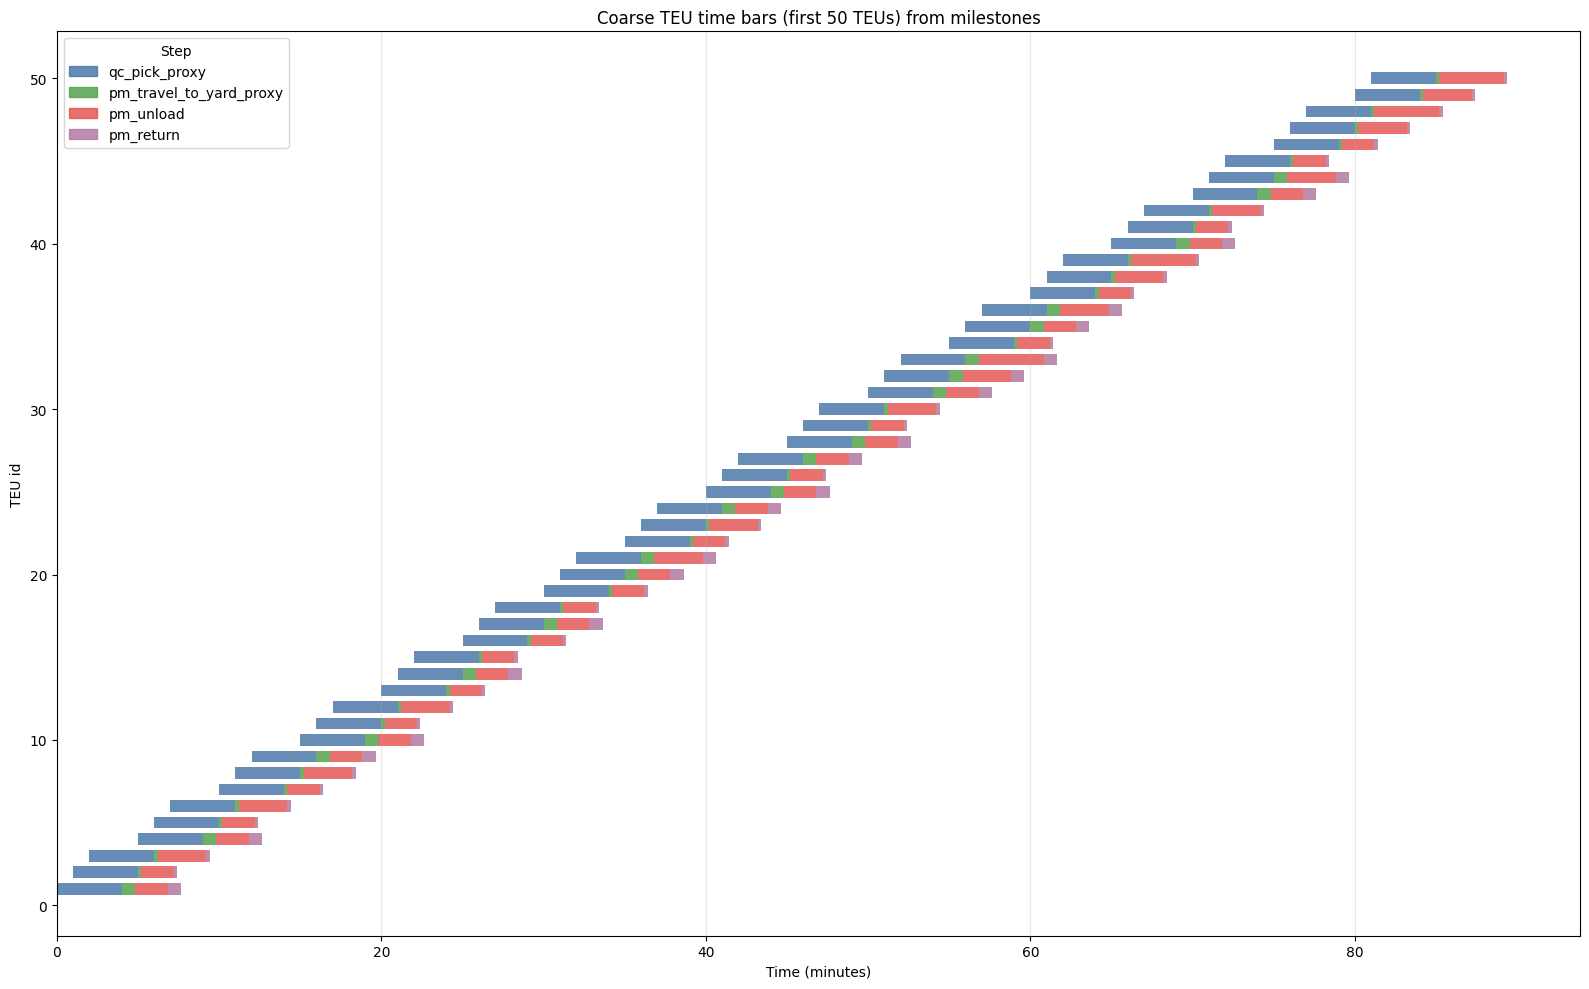

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mil = pd.read_csv("activity_summary_milestones_formatted.csv")

step_specs = [
    ("qc_pick_proxy", "qc_pick_start_min", "qc_load_to_pm_stop_min", "#4C78A8"),
    ("pm_travel_to_yard_proxy", "qc_load_to_pm_stop_min", "pm_travel_to_yard_stop_min", "#54A24B"),
    ("pm_unload", "pm_travel_to_yard_stop_min", "pm_unload_stop_min", "#E45756"),
    ("pm_return", "pm_unload_stop_min", "pm_return_stop_min", "#B279A2"),
]

fig, ax = plt.subplots(figsize=(16, 10))

mil2 = mil.sort_values("teu_id")
N = 50
mil2 = mil2[mil2["teu_id"] <= N]

for _, r in mil2.iterrows():
    y = r["teu_id"]
    for step, t0_col, t1_col, color in step_specs:
        t0 = r.get(t0_col, np.nan)
        t1 = r.get(t1_col, np.nan)
        if pd.notna(t0) and pd.notna(t1) and t1 >= t0:
            ax.barh(y=y, left=t0, width=t1 - t0, height=0.7, color=color, alpha=0.85)

ax.set_title(f"Coarse TEU time bars (first {N} TEUs) from milestones")
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("TEU id")
ax.grid(True, axis="x", alpha=0.3)

handles = [plt.Rectangle((0,0),1,1,color=c, alpha=0.85) for _,_,_,c in step_specs]
ax.legend(handles, [s for s,_,_,_ in step_specs], title="Step")

plt.tight_layout()
plt.show()

C:\Users\VPAV\AppData\Local\Temp\ipykernel_24088\1983035326.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 5)


Text(0.5, 1.0, 'PM cycle stages over time (stage heatmap)')

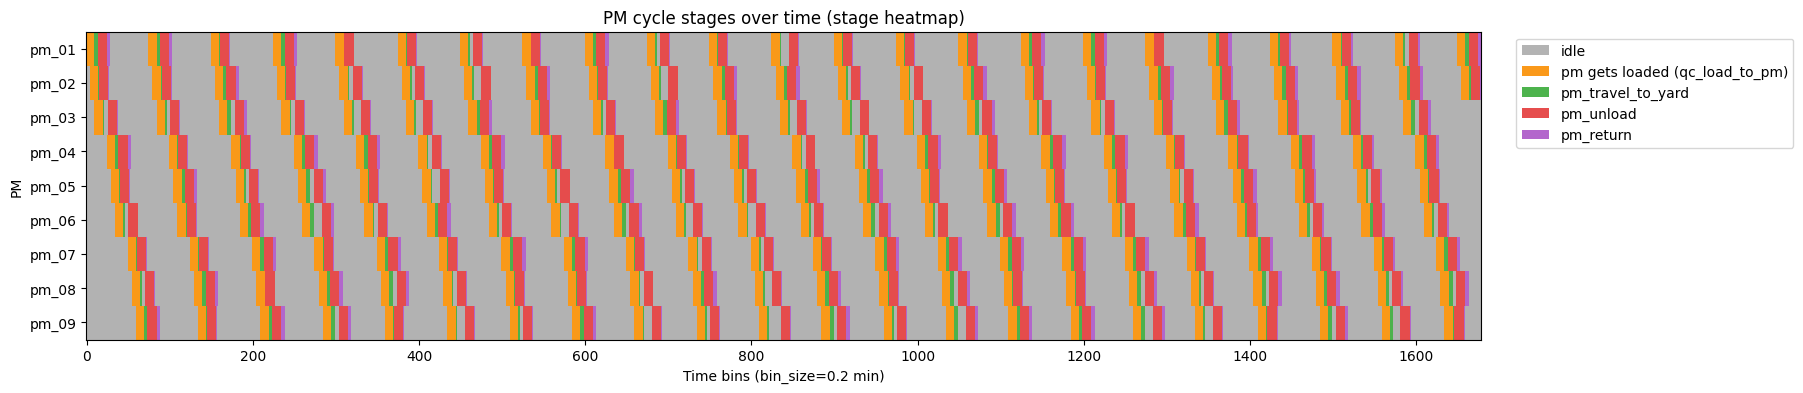

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("activity_sequence_logs.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
min_ts = df["Timestamp"].min()
df["t_min"] = (df["Timestamp"] - min_ts).dt.total_seconds() / 60.0

# Define PM cycle stages and how we map events -> stage
# qc_load_to_pm is the "PM gets loaded" stage
stage_to_activity = {
    "pm_get_loaded": "qc_load_to_pm",
    "pm_travel_to_yard": "pm_travel_to_yard",
    "pm_unload": "pm_unload",
    "pm_return": "pm_return",
}

# Event types we need
needed_activity_types = list(stage_to_activity.values())

d = df[
    (df["ActivityState"].isin(["START", "STOP"])) &
    (df["activity_type"].isin(needed_activity_types)) &
    (df["pm_name"].notna())
].copy()

# time binning
bin_size = 0.2  # minutes
t_start = float(d["t_min"].min())
t_end = float(d["t_min"].max())
grid = np.arange(t_start, t_end + 1e-9, bin_size)

pm_names = sorted(d["pm_name"].unique())
pm_index = {pm:i for i, pm in enumerate(pm_names)}

# Build stage matrix:
# code: 0=idle, 1=get_loaded, 2=travel, 3=unload, 4=return
stage_code = {
    "idle": 0,
    "pm_get_loaded": 1,
    "pm_travel_to_yard": 2,
    "pm_unload": 3,
    "pm_return": 4,
}

mat = np.zeros((len(pm_names), len(grid)-1), dtype=int)  # time bins

# For each PM and each activity instance, fill the overlapping bins
# We use activity_name as the unique instance key (safe from your log sample).
for _, r in d.iterrows():
    pass

intervals = []
for (pm, act_name, act_type), g in d.groupby(["pm_name", "activity_name", "activity_type"], dropna=False):
    start = g.loc[g["ActivityState"]=="START", "t_min"].min()
    stop = g.loc[g["ActivityState"]=="STOP", "t_min"].max()
    if pd.notna(start) and pd.notna(stop) and stop >= start:
        intervals.append((pm, act_type, start, stop, act_name))

# Fill bins
activity_to_stage = {v: k for k, v in stage_to_activity.items()}

for pm, act_type, start, stop, act_name in intervals:
    stage = activity_to_stage.get(act_type)
    code = stage_code[stage]
    i = pm_index[pm]

    # bin overlap
    b0 = int(np.floor((start - t_start) / bin_size))
    b1 = int(np.ceil((stop - t_start) / bin_size))
    b0 = max(0, b0)
    b1 = min(mat.shape[1]-1, b1-1)

    if b1 >= b0:
        mat[i, b0:b1+1] = code

# Plot categorical heatmap via discrete colormap
cmap = plt.cm.get_cmap("tab10", 5)
# Colors:
# 0 idle -> gray
# 1 load -> orange
# 2 travel -> green
# 3 unload -> red
# 4 return -> purple
colors = {
    0: (0.7, 0.7, 0.7, 1.0),
    1: (0.98, 0.60, 0.10, 1.0),
    2: (0.30, 0.70, 0.30, 1.0),
    3: (0.90, 0.30, 0.30, 1.0),
    4: (0.70, 0.40, 0.80, 1.0),
}

# Create an RGB image for each code
img = np.zeros((mat.shape[0], mat.shape[1], 3))
for code, rgba in colors.items():
    mask = (mat == code)
    img[mask] = rgba[:3]

plt.figure(figsize=(18, max(4, len(pm_names)*0.35)))
plt.imshow(img, aspect="auto", interpolation="nearest")

plt.yticks(range(len(pm_names)), pm_names)
plt.xlabel(f"Time bins (bin_size={bin_size} min)")
plt.ylabel("PM")

# Legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor=colors[0], label="idle"),
    Patch(facecolor=colors[1], label="pm gets loaded (qc_load_to_pm)"),
    Patch(facecolor=colors[2], label="pm_travel_to_yard"),
    Patch(facecolor=colors[3], label="pm_unload"),
    Patch(facecolor=colors[4], label="pm_return"),
]
plt.legend(handles=legend_items, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.title("PM cycle stages over time (stage heatmap)")

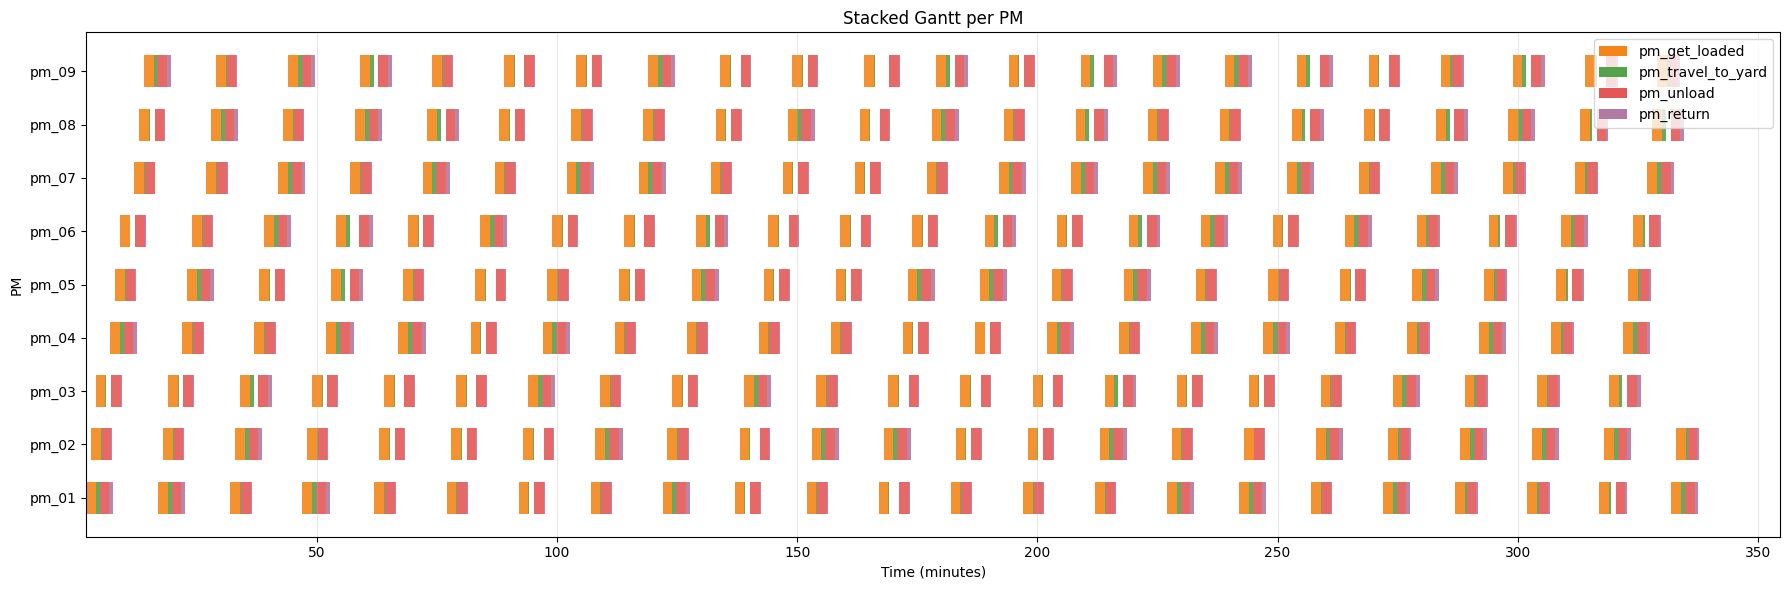

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv("activity_sequence_logs.csv")

# Parse time
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
min_ts = df["Timestamp"].min()
df["t_min"] = (df["Timestamp"] - min_ts).dt.total_seconds() / 60.0

# Stage mapping
stage_of = {
    "qc_load_to_pm": "pm_get_loaded",
    "pm_travel_to_yard": "pm_travel_to_yard",
    "pm_unload": "pm_unload",
    "pm_return": "pm_return",
}
pm_steps = list(stage_of.keys())

# Ensure activity_name exists (required for extracting pm)
if "activity_name" not in df.columns:
    raise KeyError(f"'activity_name' column missing. Columns are: {df.columns.tolist()}")

# Extract pm_name from activity_name
def extract_pm_name(activity_name: str):
    m = re.search(r"(pm_\d{2})", str(activity_name))
    return m.group(1) if m else None

df["pm_name_extracted"] = df["activity_name"].apply(extract_pm_name)

# Filter relevant rows
d = df[
    (df["ActivityState"].isin(["START", "STOP"])) &
    (df["activity_type"].isin(pm_steps)) &
    (df["pm_name_extracted"].notna())
].copy()

d["stage"] = d["activity_type"].map(stage_of)

# Build intervals explicitly
keys = ["pm_name_extracted", "activity_name", "activity_type", "stage"]
intervals_list = []

for key_vals, g in d.groupby(keys, dropna=False):
    pm, act_name, act_type, stage = key_vals
    start = g.loc[g["ActivityState"] == "START", "t_min"].min()
    stop = g.loc[g["ActivityState"] == "STOP", "t_min"].max()

    if pd.notna(start) and pd.notna(stop) and stop >= start:
        intervals_list.append({
            "pm_name": pm,
            "activity_name": act_name,
            "activity_type": act_type,
            "stage": stage,
            "start_min": start,
            "stop_min": stop,
        })

intervals = pd.DataFrame(intervals_list)

if intervals.empty:
    raise SystemExit("No intervals found. Check that START/STOP exist for each activity and that pm is extractable from activity_name.")

# Plot
colors = {
    "pm_get_loaded": "#F58518",
    "pm_travel_to_yard": "#54A24B",
    "pm_unload": "#E45756",
    "pm_return": "#B279A2",
}

pm_names = sorted(intervals["pm_name"].unique())
y_map = {pm: i for i, pm in enumerate(pm_names)}

fig, ax = plt.subplots(figsize=(18, max(6, len(pm_names) * 0.6)))
height = 0.6

for _, r in intervals.iterrows():
    y = y_map[r["pm_name"]]
    ax.barh(
        y=y,
        left=r["start_min"],
        width=r["stop_min"] - r["start_min"],
        height=height,
        color=colors.get(r["stage"], "gray"),
        alpha=0.9,
        edgecolor="none"
    )

ax.set_yticks(list(y_map.values()))
ax.set_yticklabels(list(y_map.keys()))
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("PM")
ax.set_title("Stacked Gantt per PM")
ax.grid(True, axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_items = [Patch(facecolor=colors[k], label=k) for k in ["pm_get_loaded","pm_travel_to_yard","pm_unload","pm_return"]]
ax.legend(handles=legend_items, loc="upper right")

plt.tight_layout()
plt.show()

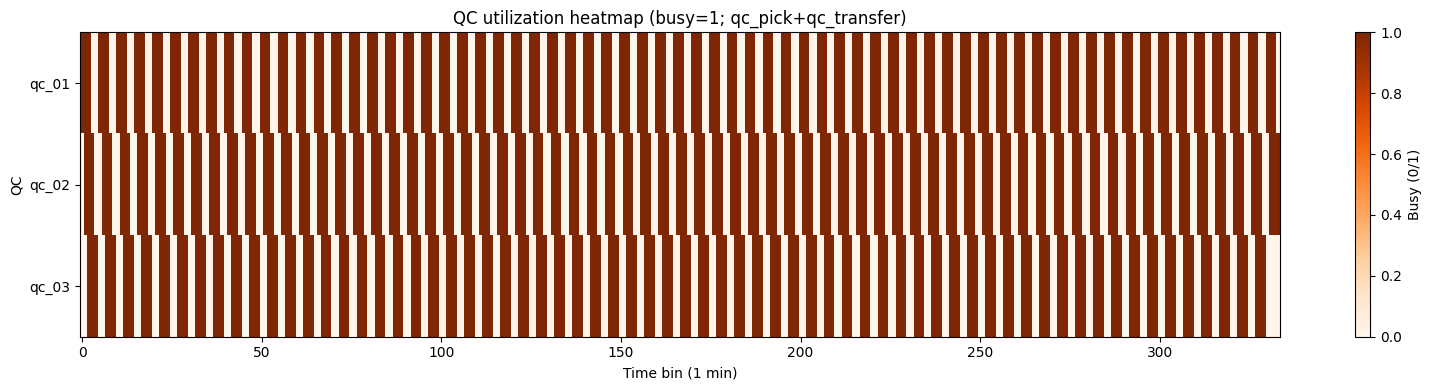

In [6]:
qc_steps = ["qc_pick", "qc_transfer"]

d = df[
    (df["ActivityState"].isin(["START", "STOP"])) &
    (df["activity_type"].isin(qc_steps))
].copy()

def extract_qc_name(activity_name: str):
    m = re.search(r"(qc_\d{2})", str(activity_name))
    return m.group(1) if m else None

d["qc_name"] = d["activity_name"].apply(extract_qc_name)
d = d.dropna(subset=["qc_name"])

intervals = (
    d.groupby(["qc_name", "activity_name"], dropna=False)
     .apply(lambda g: pd.Series({
         "start_min": g.loc[g["ActivityState"]=="START", "t_min"].min(),
         "stop_min":  g.loc[g["ActivityState"]=="STOP",  "t_min"].max(),
     }))
     .reset_index()
)

intervals = intervals.dropna(subset=["start_min", "stop_min"])
intervals = intervals[intervals["stop_min"] >= intervals["start_min"]]

qc_names = sorted(intervals["qc_name"].unique())
t_end = float(intervals["stop_min"].max())
bin_size = 1.0
grid = np.arange(0, t_end + 1e-9, bin_size)

mat = np.zeros((len(qc_names), len(grid)))

qc_index = {qc:i for i, qc in enumerate(qc_names)}
for _, r in intervals.iterrows():
    qc = r["qc_name"]
    i = qc_index[qc]
    start_bin = int(np.floor(r["start_min"] / bin_size))
    stop_bin = int(np.ceil(r["stop_min"] / bin_size))
    start_bin = max(0, start_bin)
    stop_bin = min(len(grid)-1, stop_bin)
    mat[i, start_bin:stop_bin+1] = 1

plt.figure(figsize=(16, max(4, len(qc_names)*0.4)))
plt.imshow(mat, aspect="auto", interpolation="nearest", cmap="Oranges")
plt.colorbar(label="Busy (0/1)")
plt.yticks(range(len(qc_names)), qc_names)
plt.xlabel("Time bin (1 min)")
plt.ylabel("QC")
plt.title("QC utilization heatmap (busy=1; qc_pick+qc_transfer)")
plt.tight_layout()
plt.show()

      qc  avg_pm_wait_proxy_min  median_pm_wait_proxy_min  teu_count
2  qc_03               5.818175                  5.637572         66
1  qc_02               5.355498                  5.409393         67
0  qc_01               5.114688                  5.409393         67


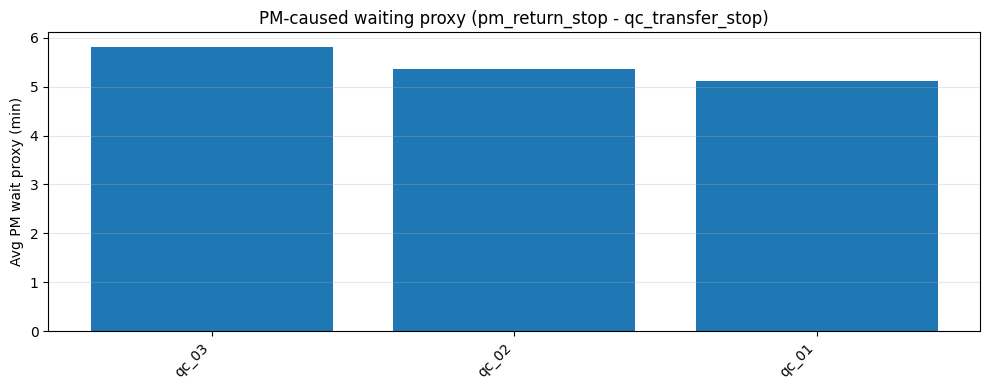

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("activity_sequence_logs.csv")

# Parse timestamp to minutes
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
min_ts = df["Timestamp"].min()
df["t_min"] = (df["Timestamp"] - min_ts).dt.total_seconds() / 60.0

# Keep only START/STOP for relevant activity types
keep_types = ["qc_transfer", "qc_load_to_pm", "pm_return", "qc_pick"]
df = df[df["ActivityState"].isin(["START", "STOP"])].copy()
df = df[df["activity_type"].isin(keep_types)].copy()

# Build a lookup table for qc_transfer_stop, qc_load_start, pm_return_stop per teu_id
def first_stop(teu_df, activity_type):
    rows = teu_df[(teu_df["activity_type"] == activity_type) & (teu_df["ActivityState"] == "STOP")]
    return rows["t_min"].min() if not rows.empty else np.nan

def first_start(teu_df, activity_type):
    rows = teu_df[(teu_df["activity_type"] == activity_type) & (teu_df["ActivityState"] == "START")]
    return rows["t_min"].min() if not rows.empty else np.nan

rows = []
for teu_id, g in df.groupby("teu_id"):
    g = g.copy()
    qc_transfer_stop = first_stop(g, "qc_transfer")
    qc_load_start = first_start(g, "qc_load_to_pm")
    pm_return_stop = first_stop(g, "pm_return")

    # qc id from qc_pick activity_name is easiest if present;
    # if qc isn't in logs, you can join from teu_df later.
    qc_from_pick = np.nan
    pick_rows = g[(g["activity_type"] == "qc_pick") & (g["ActivityState"] == "START")]
    if not pick_rows.empty and "activity_name" in pick_rows.columns:
        import re
        m = re.search(r"(qc_\d{2})", str(pick_rows["activity_name"].iloc[0]))
        qc_from_pick = m.group(1) if m else np.nan

    rows.append({
        "teu_id": int(teu_id),
        "qc": qc_from_pick,
        "qc_transfer_stop_min": qc_transfer_stop,
        "qc_load_start_min": qc_load_start,
        "pm_return_stop_min": pm_return_stop,
    })

teu_wait = pd.DataFrame(rows)

# PM-caused wait proxy: how much later the PM return is than QC transfer
teu_wait["pm_wait_proxy_min"] = np.where(
    pd.notna(teu_wait["pm_return_stop_min"]) & pd.notna(teu_wait["qc_transfer_stop_min"]),
    np.maximum(0, teu_wait["pm_return_stop_min"] - teu_wait["qc_transfer_stop_min"]),
    np.nan
)

# Summarize by QC
summary = (
    teu_wait.dropna(subset=["qc", "pm_wait_proxy_min"])
    .groupby("qc", as_index=False)
    .agg(
        avg_pm_wait_proxy_min=("pm_wait_proxy_min", "mean"),
        median_pm_wait_proxy_min=("pm_wait_proxy_min", "median"),
        teu_count=("teu_id", "count"),
    )
    .sort_values("avg_pm_wait_proxy_min", ascending=False)
)

print(summary)
summary.to_csv("qc_pm_wait_proxy_summary.csv", index=False)

plt.figure(figsize=(10,4))
plt.bar(summary["qc"], summary["avg_pm_wait_proxy_min"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Avg PM wait proxy (min)")
plt.title("PM-caused waiting proxy (pm_return_stop - qc_transfer_stop)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

TEUs handled by qc_01 (first 10): [1, 4, 7, 10, 13, 16, 19, 22, 25, 28]


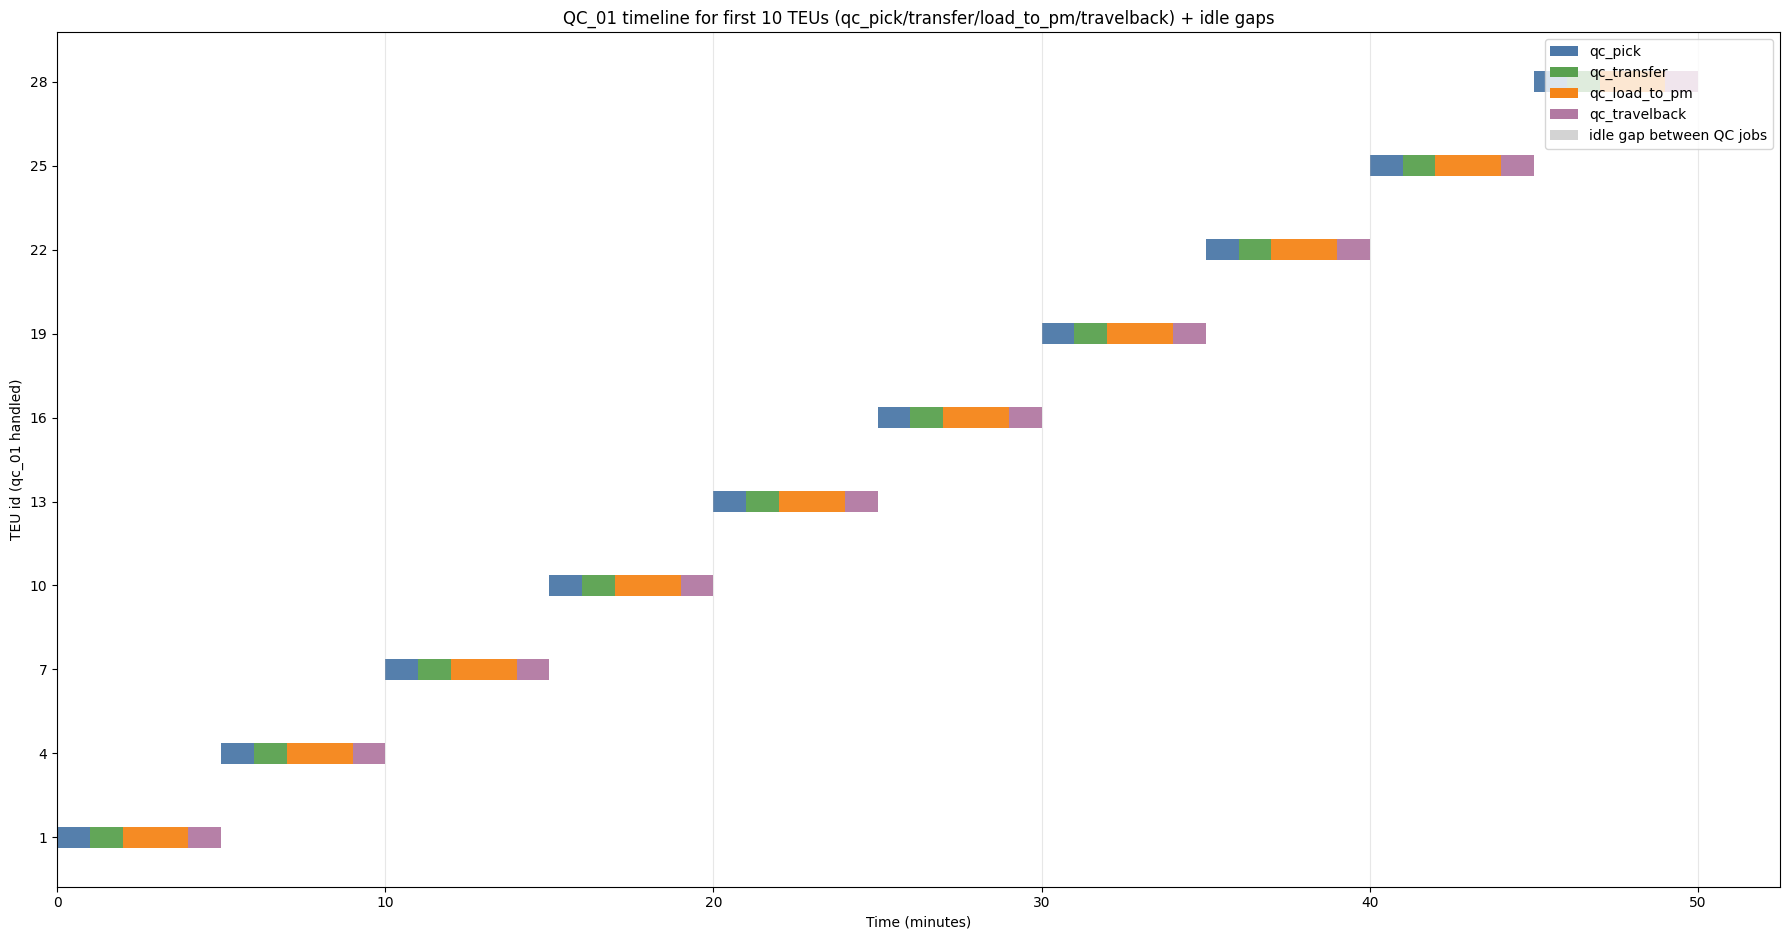

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv("activity_sequence_logs.csv")

# Parse time
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
min_ts = df["Timestamp"].min()
df["t_min"] = (df["Timestamp"] - min_ts).dt.total_seconds() / 60.0

# Keep START/STOP
df = df[df["ActivityState"].isin(["START","STOP"])].copy()

qc_id = "qc_01"
qc_steps = ["qc_pick", "qc_transfer", "qc_load_to_pm", "qc_travelback"]

# 1) Identify TEUs handled by qc_01 using qc_pick activity_name
# Extract qc_XX from activity_name for qc_pick rows
def extract_qc_from_activity_name(name: str):
    m = re.search(r"(qc_\d{2})", str(name))
    return m.group(1) if m else None

qc_pick = df[(df["activity_type"] == "qc_pick")].copy()
qc_pick["qc_extracted"] = qc_pick["activity_name"].apply(extract_qc_from_activity_name)

teus_qc = qc_pick[qc_pick["qc_extracted"] == qc_id][["teu_id", "t_min"]].copy()
# pick first 10 TEUs by earliest qc_pick START
teus_first10 = (
    qc_pick[qc_pick["qc_extracted"] == qc_id]
    .groupby("teu_id")["t_min"].min()
    .sort_values()
    .head(10)
    .index.tolist()
)

print("TEUs handled by qc_01 (first 10):", teus_first10)

# 2) Extract intervals for qc steps for those TEUs (no qc filtering on activity_name)
dqc = df[
    (df["teu_id"].isin(teus_first10)) &
    (df["activity_type"].isin(qc_steps))
].copy()

# interval per teu_id + activity_type + activity_name (activity_name is stable enough)
intervals = (
    dqc.groupby(["teu_id", "activity_type", "activity_name"], dropna=False)
       .apply(lambda g: pd.Series({
           "start_min": g.loc[g["ActivityState"]=="START", "t_min"].min(),
           "stop_min":  g.loc[g["ActivityState"]=="STOP", "t_min"].max(),
       }))
       .reset_index()
)

intervals = intervals.dropna(subset=["start_min","stop_min"])
intervals = intervals[intervals["stop_min"] >= intervals["start_min"]].copy()

order_map = {"qc_pick":1, "qc_transfer":2, "qc_load_to_pm":3, "qc_travelback":4}
intervals["activity_order"] = intervals["activity_type"].map(order_map).fillna(999)

# map y positions by TEU order (based on qc_pick start)
teu_pick_start = (
    intervals[intervals["activity_type"]=="qc_pick"]
    .groupby("teu_id")["start_min"].min()
    .sort_values()
)
ordered_teus = teu_pick_start.index.tolist()
y_map = {teu:i for i, teu in enumerate(ordered_teus)}

colors = {
    "qc_pick": "#4C78A8",
    "qc_transfer": "#59A14F",
    "qc_load_to_pm": "#F58518",
    "qc_travelback": "#B279A2",
}

fig, ax = plt.subplots(figsize=(18, 6 + len(ordered_teus)*0.35))

# QC stage bars
for _, r in intervals.iterrows():
    teu = int(r["teu_id"])
    y = y_map[teu]
    ax.barh(
        y=y,
        left=r["start_min"],
        width=r["stop_min"] - r["start_min"],
        height=0.25,
        color=colors.get(r["activity_type"], "gray"),
        alpha=0.95,
        edgecolor="none"
    )

# Idle gaps between TEU qc jobs:
# job end proxy = qc_travelback STOP if exists else qc_transfer STOP
job_end = []
for teu in ordered_teus:
    tb = intervals[(intervals["teu_id"]==teu) & (intervals["activity_type"]=="qc_travelback")]["stop_min"]
    if len(tb):
        end_time = tb.max()
    else:
        end_time = intervals[(intervals["teu_id"]==teu) & (intervals["activity_type"]=="qc_transfer")]["stop_min"].max()
    start_time = intervals[(intervals["teu_id"]==teu) & (intervals["activity_type"]=="qc_pick")]["start_min"].min()
    job_end.append((teu, start_time, end_time))

job_end = pd.DataFrame(job_end, columns=["teu_id","job_start","job_end"]).sort_values("job_start")

# plot idle as gaps between previous job end and next job start
for i in range(1, len(job_end)):
    prev_end = job_end.iloc[i-1]["job_end"]
    cur_start = job_end.iloc[i]["job_start"]
    if cur_start > prev_end:
        teu = int(job_end.iloc[i]["teu_id"])
        y = y_map[teu]
        ax.barh(y=y, left=prev_end, width=cur_start-prev_end, height=0.18, color="lightgray", alpha=0.9, edgecolor="none")

ax.set_yticks(range(len(ordered_teus)))
ax.set_yticklabels([str(t) for t in ordered_teus])
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("TEU id (qc_01 handled)")
ax.set_title("QC_01 timeline for first 10 TEUs (qc_pick/transfer/load_to_pm/travelback) + idle gaps")
ax.grid(True, axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor=colors["qc_pick"], label="qc_pick"),
    Patch(facecolor=colors["qc_transfer"], label="qc_transfer"),
    Patch(facecolor=colors["qc_load_to_pm"], label="qc_load_to_pm"),
    Patch(facecolor=colors["qc_travelback"], label="qc_travelback"),
    Patch(facecolor="lightgray", label="idle gap between QC jobs"),
]
ax.legend(handles=legend_items, loc="upper right")

plt.tight_layout()
plt.show()

QC_01 TEUs plotted: [1, 4, 7, 10, 13, 16, 19, 22, 25, 28]


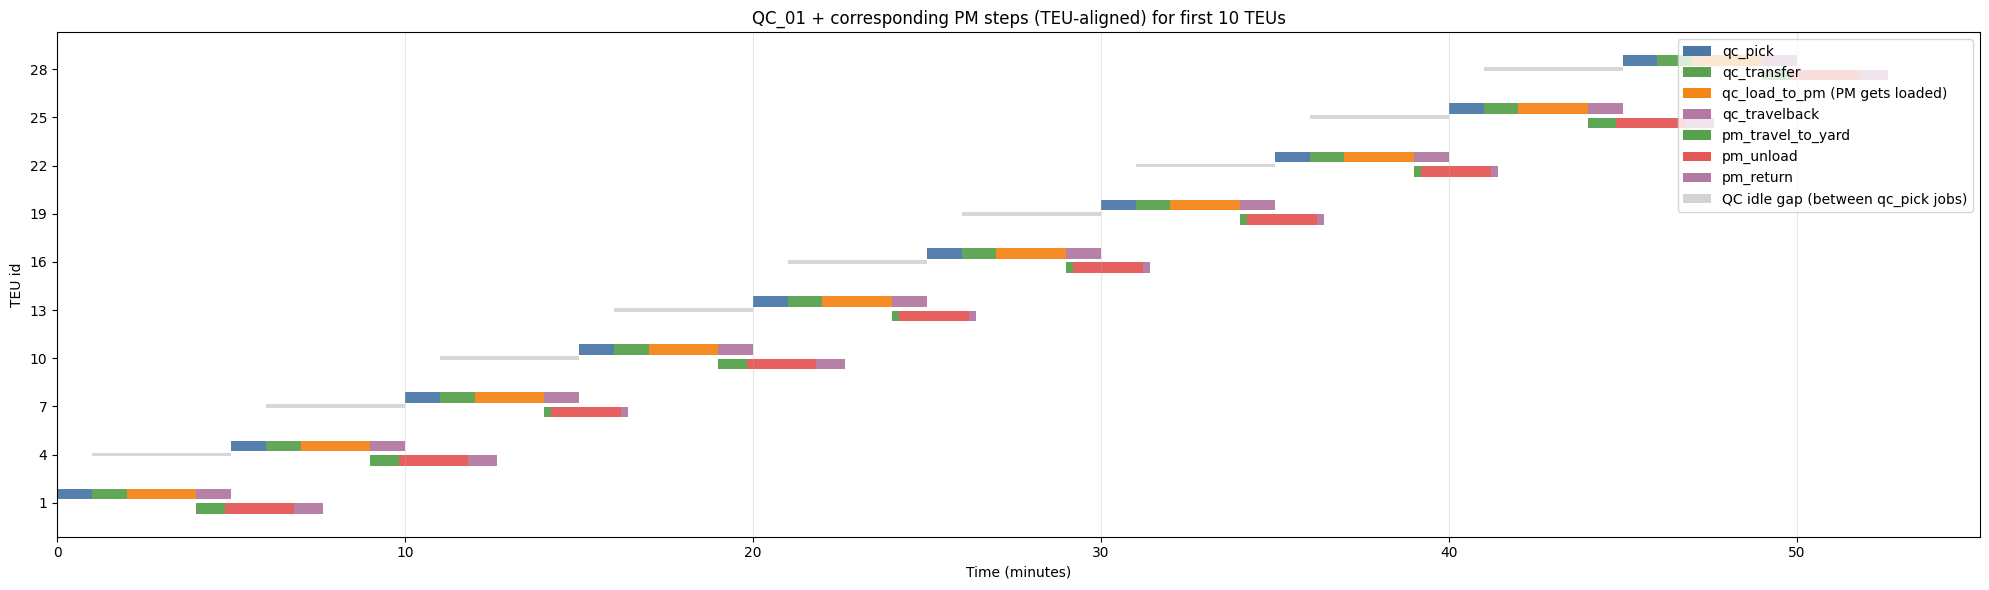

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv("activity_sequence_logs.csv")

# Parse datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
min_ts = df["Timestamp"].min()
df["t_min"] = (df["Timestamp"] - min_ts).dt.total_seconds() / 60.0

# Helper extractors
def extract_qc(name: str):
    m = re.search(r"(qc_\d{2})", str(name))
    return m.group(1) if m else None

def extract_pm(name: str):
    m = re.search(r"(pm_\d{2})", str(name))
    return m.group(1) if m else None

# Filter to relevant activity states
df = df[df["ActivityState"].isin(["START", "STOP"])].copy()

qc_id = "qc_01"
qc_steps = ["qc_pick", "qc_transfer", "qc_load_to_pm", "qc_travelback"]
pm_steps = ["pm_travel_to_yard", "pm_unload", "pm_return"]

# 1) Determine TEUs handled by qc_01 using qc_pick activity
qc_pick = df[(df["activity_type"] == "qc_pick")].copy()
qc_pick["qc_extracted"] = qc_pick["activity_name"].apply(extract_qc)

teus = qc_pick[qc_pick["qc_extracted"] == qc_id].groupby("teu_id")["t_min"].min().sort_values().index.tolist()

# Optional: limit to first N TEUs for readability
N = 10
teus = teus[:N]

print("QC_01 TEUs plotted:", teus)

# 2) For each TEU, determine which PM was used:
# Use qc_load_to_pm activity: it includes pm in activity_name
qc_load = df[(df["activity_type"] == "qc_load_to_pm") & (df["teu_id"].isin(teus))].copy()
qc_load["pm_used"] = qc_load["activity_name"].apply(extract_pm)

pm_used_by_teu = (
    qc_load.sort_values("t_min")
    .groupby("teu_id")["pm_used"]
    .first()
    .to_dict()
)

# 3) Build QC intervals
dqc = df[(df["teu_id"].isin(teus)) & (df["activity_type"].isin(qc_steps))].copy()

qc_intervals = (
    dqc.groupby(["teu_id", "activity_type", "activity_name"], dropna=False)
       .apply(lambda g: pd.Series({
           "start_min": g.loc[g["ActivityState"]=="START", "t_min"].min(),
           "stop_min":  g.loc[g["ActivityState"]=="STOP",  "t_min"].max(),
       }))
       .reset_index()
)
qc_intervals = qc_intervals.dropna(subset=["start_min","stop_min"])
qc_intervals = qc_intervals[qc_intervals["stop_min"] >= qc_intervals["start_min"]].copy()

# QC activity colors
qc_colors = {
    "qc_pick": "#4C78A8",
    "qc_transfer": "#59A14F",
    "qc_load_to_pm": "#F58518",
    "qc_travelback": "#B279A2",
}

# 4) Build PM intervals per TEU for its assigned PM
# We pull PM steps for each TEU and only the PM assigned to that TEU
dpm = df[(df["teu_id"].isin(teus)) & (df["activity_type"].isin(pm_steps))].copy()
dpm["pm_extracted"] = dpm["activity_name"].apply(extract_pm)

# Assign pm_used to each row by teu_id
dpm["pm_assigned"] = dpm["teu_id"].map(pm_used_by_teu)

# Keep only rows where extracted PM matches assigned PM
dpm = dpm[dpm["pm_extracted"] == dpm["pm_assigned"]].copy()

pm_intervals = (
    dpm.groupby(["teu_id", "activity_type", "activity_name"], dropna=False)
       .apply(lambda g: pd.Series({
           "start_min": g.loc[g["ActivityState"]=="START", "t_min"].min(),
           "stop_min":  g.loc[g["ActivityState"]=="STOP",  "t_min"].max(),
       }))
       .reset_index()
)
pm_intervals = pm_intervals.dropna(subset=["start_min","stop_min"])
pm_intervals = pm_intervals[pm_intervals["stop_min"] >= pm_intervals["start_min"]].copy()

pm_colors = {
    "pm_travel_to_yard": "#54A24B",
    "pm_unload": "#E45756",
    "pm_return": "#B279A2",
}

# 5) Plot combined figure
# One TEU per row. We'll draw QC bars on upper half of the row and PM bars slightly below.
teus_order = sorted(teus)
y_map = {teu:i for i, teu in enumerate(teus_order)}

fig, ax = plt.subplots(figsize=(20, max(6, len(teus_order)*0.45)))

qc_height = 0.22
pm_height = 0.22
qc_y_offset = 0.18
pm_y_offset = -0.12

# QC bars
for _, r in qc_intervals.iterrows():
    teu = int(r["teu_id"])
    y = y_map[teu] + qc_y_offset
    act = r["activity_type"]
    ax.barh(
        y=y,
        left=r["start_min"],
        width=r["stop_min"] - r["start_min"],
        height=qc_height,
        color=qc_colors.get(act, "gray"),
        alpha=0.95
    )

# PM bars
for _, r in pm_intervals.iterrows():
    teu = int(r["teu_id"])
    y = y_map[teu] + pm_y_offset
    act = r["activity_type"]
    ax.barh(
        y=y,
        left=r["start_min"],
        width=r["stop_min"] - r["start_min"],
        height=pm_height,
        color=pm_colors.get(act, "gray"),
        alpha=0.95
    )

# Optional: idle gaps on QC row (between qc_pick start times)
qc_pick_starts = qc_intervals[qc_intervals["activity_type"]=="qc_pick"][["teu_id","start_min","stop_min"]].copy()
qc_pick_starts = qc_pick_starts.groupby("teu_id").agg(start_min=("start_min","min"), end_min=("stop_min","max")).reset_index()
qc_pick_starts = qc_pick_starts.set_index("teu_id").loc[teus_order].reset_index()

for i in range(1, len(qc_pick_starts)):
    prev_end = qc_pick_starts.loc[i-1, "end_min"]
    cur_start = qc_pick_starts.loc[i, "start_min"]
    if cur_start > prev_end:
        teu = int(qc_pick_starts.loc[i, "teu_id"])
        y = y_map[teu]  # center idle around the row
        ax.barh(
            y=y,
            left=prev_end,
            width=cur_start - prev_end,
            height=0.08,
            color="lightgray",
            alpha=0.9,
            edgecolor="none"
        )

ax.set_yticks(range(len(teus_order)))
ax.set_yticklabels([str(t) for t in teus_order])
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("TEU id")
ax.set_title(f"QC_01 + corresponding PM steps (TEU-aligned) for first {len(teus_order)} TEUs")

# Legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor=qc_colors["qc_pick"], label="qc_pick"),
    Patch(facecolor=qc_colors["qc_transfer"], label="qc_transfer"),
    Patch(facecolor=qc_colors["qc_load_to_pm"], label="qc_load_to_pm (PM gets loaded)"),
    Patch(facecolor=qc_colors["qc_travelback"], label="qc_travelback"),
    Patch(facecolor=pm_colors["pm_travel_to_yard"], label="pm_travel_to_yard"),
    Patch(facecolor=pm_colors["pm_unload"], label="pm_unload"),
    Patch(facecolor=pm_colors["pm_return"], label="pm_return"),
    Patch(facecolor="lightgray", label="QC idle gap (between qc_pick jobs)"),
]
ax.legend(handles=legend_items, loc="upper right")

ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()